# Task 2 — Notebook 04: Spatial maps

Rotation class GeoTIFFs (**raw** and **smoothed**) with **13-state Corn Belt** boundary overlays (not a two-state Iowa/Nebraska view). On-map notes are **illustrative**: four **geographic zones** (eastern IA/IL core, central Plains / NE monoculture, northern / Lakes fringe irregularity, east–west gradient). Exact placement depends on your raster extent.

**Boundaries (in order):**
1. If ``data/external/states/*.shp`` exists, the first shapefile is loaded and rows are filtered to the **13-state Corn Belt** in ``configs/task2_crop_rotation.yaml`` ``study_area.states`` (by ``NAME`` / ``NAME_1`` / ``name`` when present), then reprojected to **EPSG:5070**.
2. Otherwise **Natural Earth 110m** admin-1 (same 13 U.S. states) is downloaded and reprojected to match the CDL raster CRS.

Figures are written to ``artifacts/figures/task2/`` from YAML ``output.figures_dir``. A **second figure** (cells below) saves a **core Corn Belt zoom** (IA / IL / IN / NE) using ``focus_state_names`` — no extra raster data.

**Notebook tip:** If you see ``ImportError: cannot import name 'load_cornbelt_state_boundaries_5070'`` after updating ``rotation_maps.py``, **restart the kernel** (or re-run the imports below: they ``reload`` the module so edits apply without a full restart).


State boundaries: 13 states | CRS EPSG:5070


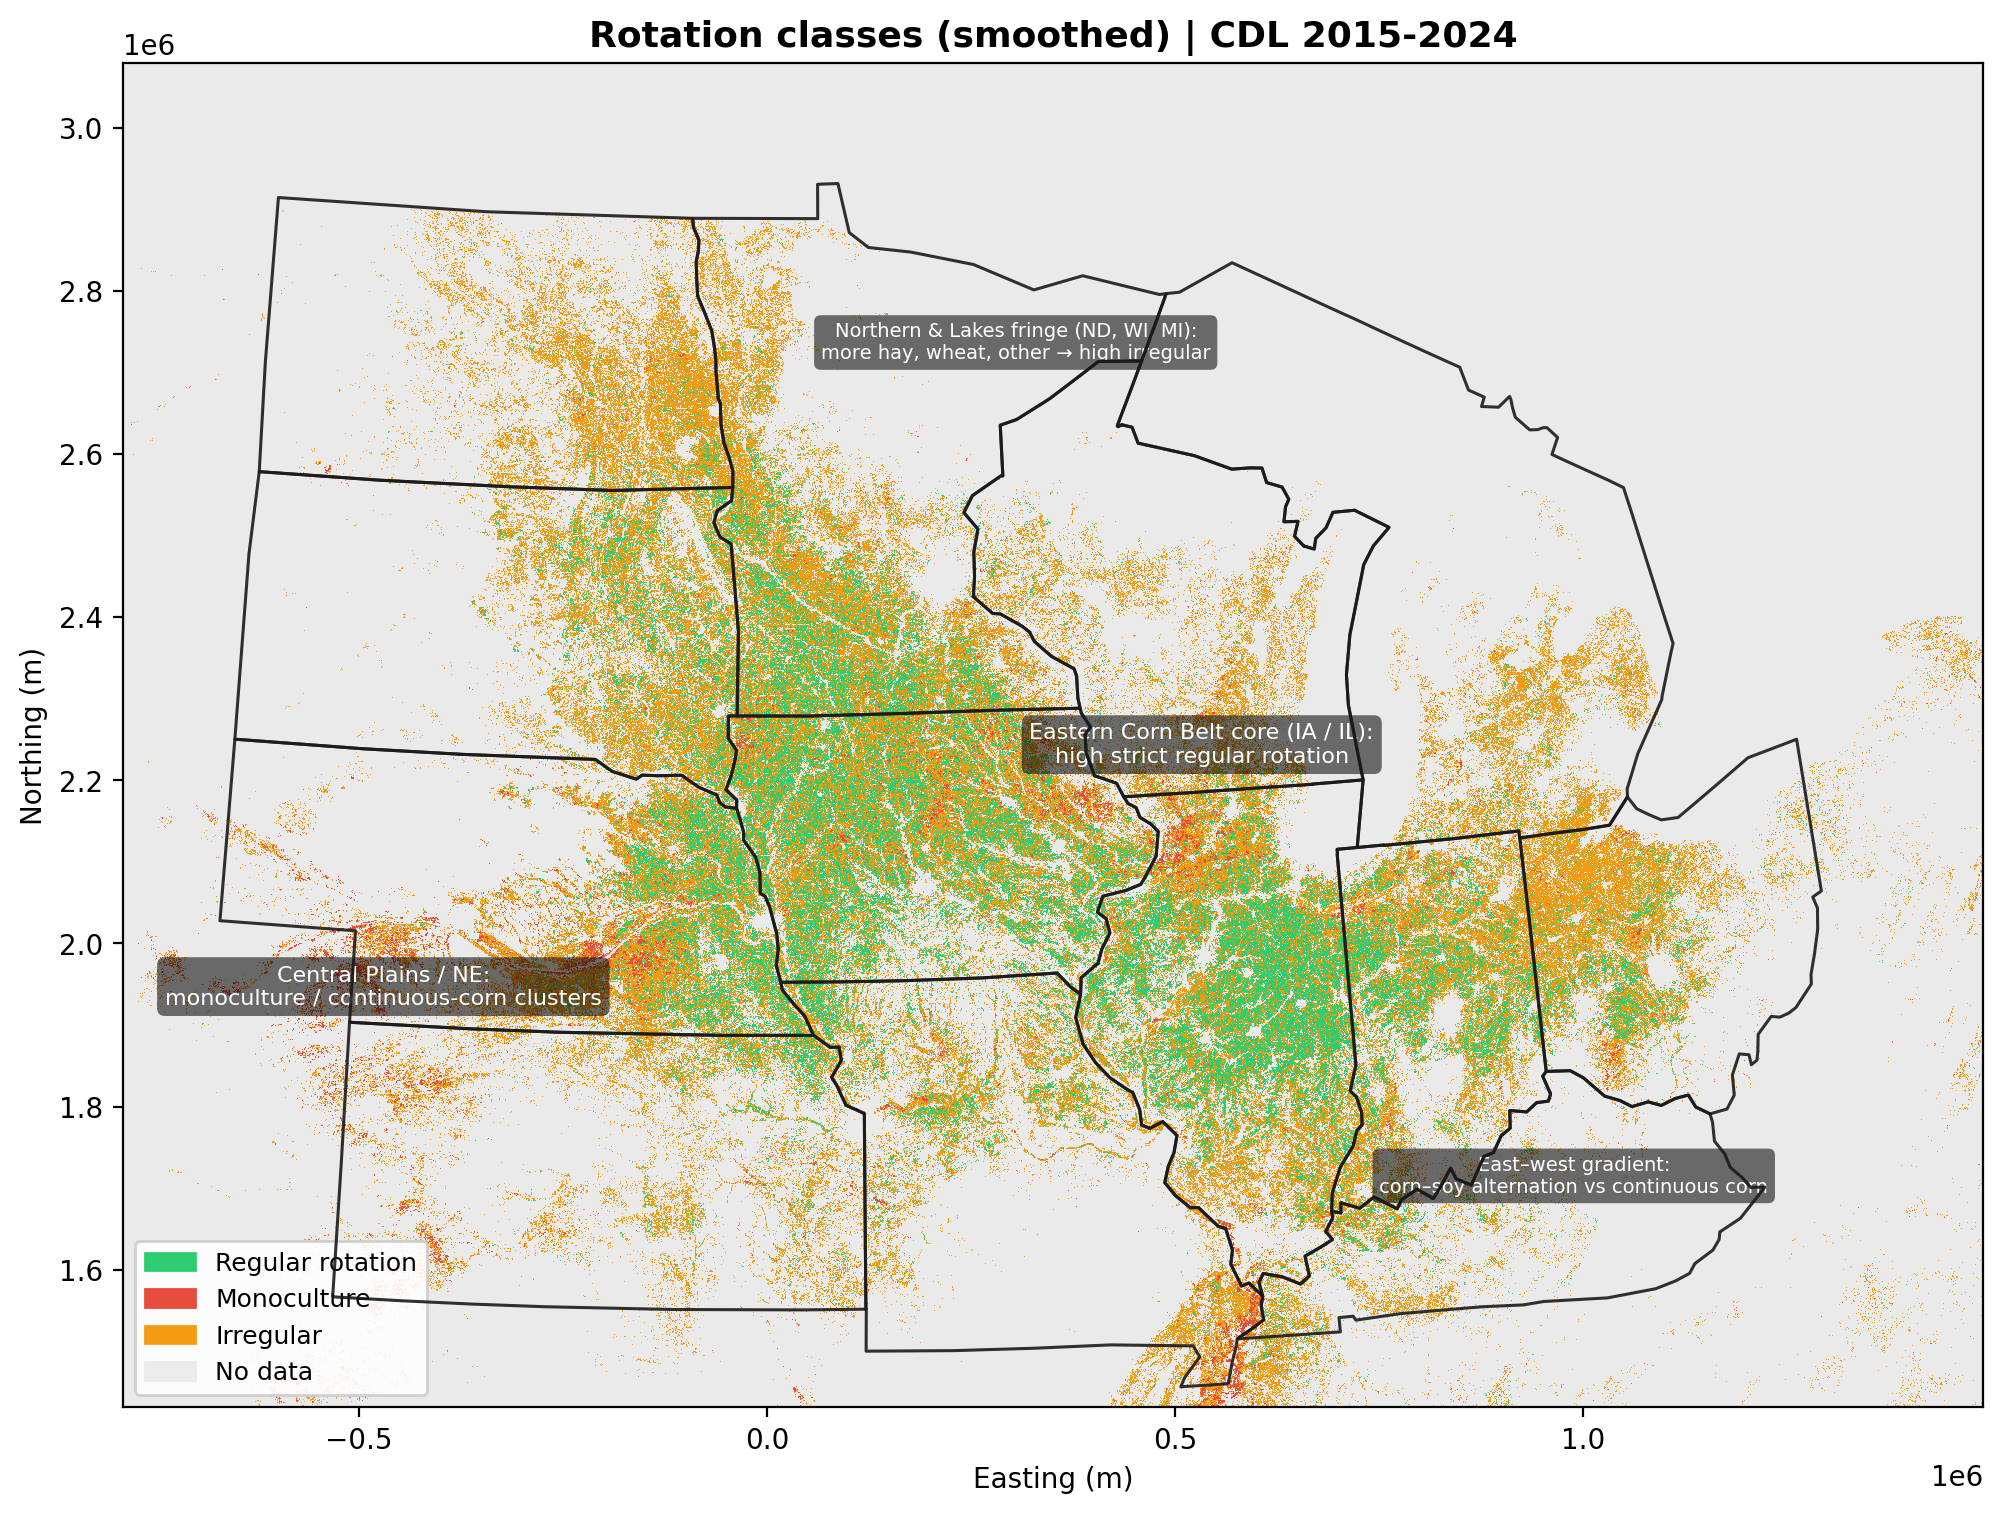

Saved artifacts\figures\task2\task2__rotation_map__smoothed__20260412.png


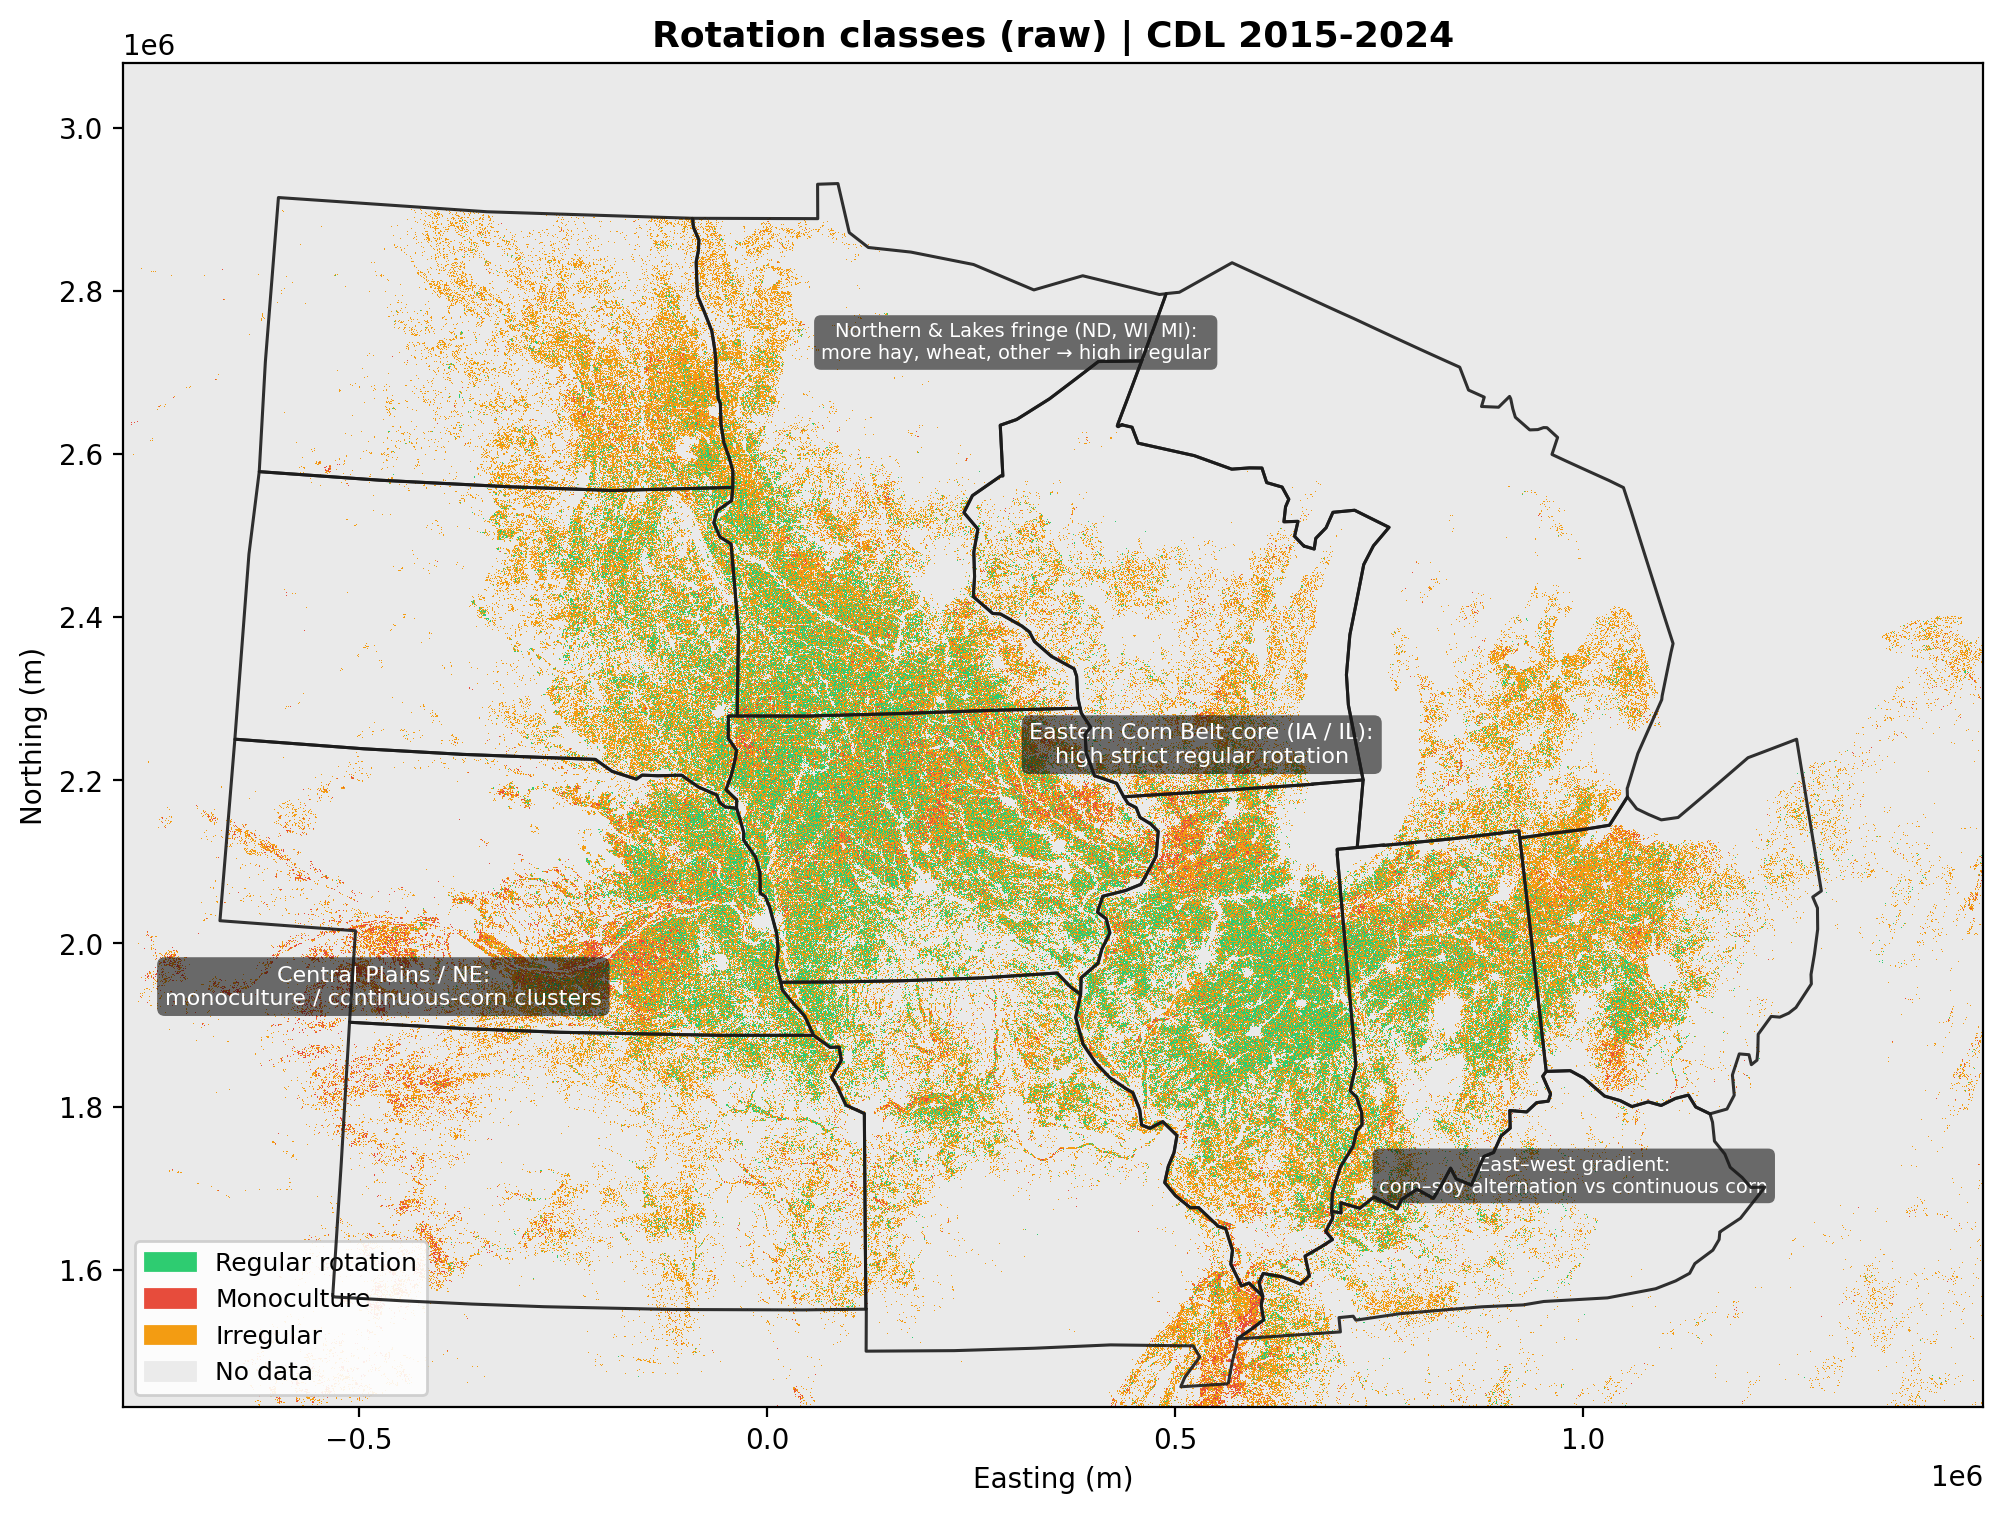

Saved artifacts\figures\task2\task2__rotation_map__raw__20260412.png


In [8]:
import importlib
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

import src.viz.rotation_maps as _rotation_maps

_rotation_maps = importlib.reload(_rotation_maps)
load_cornbelt_state_boundaries_5070 = getattr(
    _rotation_maps, "load_cornbelt_state_boundaries_5070", None
)
plot_rotation_class_map = getattr(_rotation_maps, "plot_rotation_class_map", None)
if load_cornbelt_state_boundaries_5070 is None or plot_rotation_class_map is None:
    raise ImportError(
        "Expected load_cornbelt_state_boundaries_5070 and plot_rotation_class_map in "
        "src/viz/rotation_maps.py — pull/sync the latest repo, then restart the kernel."
    )

with open(REPO_ROOT / "configs" / "task2_crop_rotation.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

_cdl_y0, _cdl_y1 = cfg["cdl"]["year_range"]
_cdl_span = f"CDL {_cdl_y0}-{_cdl_y1}"

out_dir = REPO_ROOT / cfg["output"]["processed_dir"]
fig_dir = REPO_ROOT / cfg["output"]["figures_dir"]
fig_dir.mkdir(parents=True, exist_ok=True)

states = load_cornbelt_state_boundaries_5070(REPO_ROOT)
if states is None:
    print("State boundaries: unavailable (install geopandas; for offline use add a shapefile under data/external/states/).")
else:
    print("State boundaries:", len(states), "states | CRS", states.crs)

for label, fname in ("smoothed", "rotation_class_map_smoothed.tif"), ("raw", "rotation_class_map.tif"):
    p = out_dir / fname
    if not p.is_file():
        print("skip missing", p)
        continue
    fig, ax = plot_rotation_class_map(
        p,
        state_shapes=states,
        title=f"Rotation classes ({label}) | {_cdl_span}",
    )
    xl, xr = ax.get_xlim()
    yb, yt = ax.get_ylim()
    ax.annotate(
        "Eastern Corn Belt core (IA / IL):\nhigh strict regular rotation",
        xy=(xl + 0.58 * (xr - xl), yb + 0.48 * (yt - yb)),
        fontsize=8,
        color="white",
        ha="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="black", ec="none", alpha=0.55),
    )
    ax.annotate(
        "Central Plains / NE:\nmonoculture / continuous-corn clusters",
        xy=(xl + 0.14 * (xr - xl), yb + 0.30 * (yt - yb)),
        fontsize=8,
        color="white",
        ha="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="black", ec="none", alpha=0.55),
    )
    ax.annotate(
        "Northern & Lakes fringe (ND, WI, MI):\nmore hay, wheat, other → high irregular",
        xy=(xl + 0.48 * (xr - xl), yb + 0.78 * (yt - yb)),
        fontsize=7,
        color="white",
        ha="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="black", ec="none", alpha=0.55),
    )
    ax.annotate(
        "East–west gradient:\ncorn–soy alternation vs continuous corn",
        xy=(xl + 0.78 * (xr - xl), yb + 0.16 * (yt - yb)),
        fontsize=7,
        color="white",
        ha="center",
        bbox=dict(boxstyle="round,pad=0.35", fc="black", ec="none", alpha=0.55),
    )
    outp = fig_dir / f"task2__rotation_map__{label}__{date.today():%Y%m%d}.png"
    fig.savefig(outp, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", outp.relative_to(REPO_ROOT))


## Core Corn Belt zoom (IA / IL / IN / NE)

Same **smoothed** GeoTIFF and boundary source as above. **`focus_state_names`** in `plot_rotation_class_map` limits the axis to the union of those four states (padding ~4%) so **Iowa/Illinois** (higher % regular) vs **Nebraska** (higher % monoculture) is readable at report scale. Output: **`artifacts/figures/task2/task2__rotation_map__core_belt__YYYYMMDD.png`**.

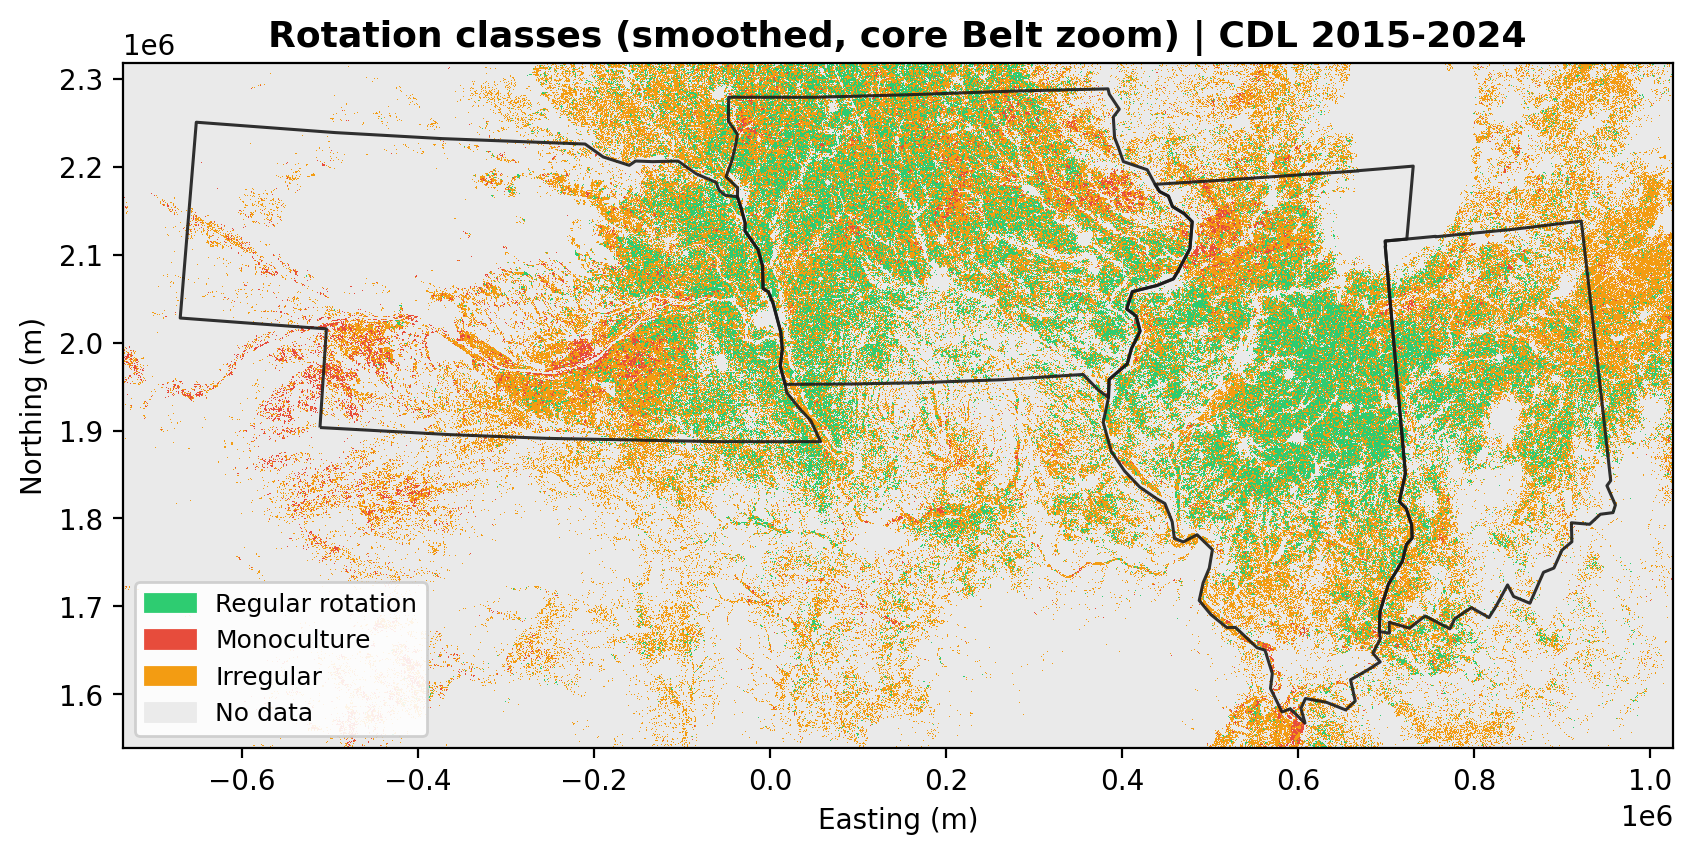

Saved artifacts\figures\task2\task2__rotation_map__core_belt__20260412.png


In [9]:
CORE_BELT_STATES = frozenset({"Iowa", "Illinois", "Indiana", "Nebraska"})
p_sm = out_dir / "rotation_class_map_smoothed.tif"
if p_sm.is_file() and states is not None and plot_rotation_class_map is not None:
    fig_z, ax_z = plot_rotation_class_map(
        p_sm,
        state_shapes=states,
        title=f"Rotation classes (smoothed, core Belt zoom) | {_cdl_span}",
        focus_state_names=CORE_BELT_STATES,
        figsize=(10, 9),
    )
    outp_z = fig_dir / f"task2__rotation_map__core_belt__{date.today():%Y%m%d}.png"
    fig_z.savefig(outp_z, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", outp_z.relative_to(REPO_ROOT))
else:
    print("Skip core-belt map: need rotation_class_map_smoothed.tif and state boundaries.")